# IPP Validation Study

This notebook validates the Índice de Profissionalização do Parlamentar (IPP) through:

1. **Confirmatory Factor Analysis (CFA)** - Testing the theoretical two-factor structure
2. **Sensitivity Analysis** - Comparing different weighting schemes
3. **Cronbach's Alpha** - Assessing internal consistency

## IPP Structure

**Dimension 1 - Especialização Legislativa (Legislative Specialization):**
- Mesa Diretora (weight: 5)
- Colégio de Líderes (weight: 4)
- Presidência de Comissão (weight: 3)
- Relatoria (weight: 2)

**Dimension 2 - Carreira Parlamentar (Parliamentary Career):**
- Mandatos Subnacionais (weight: 1)
- Tempo de Atuação (weight: 1)
- Fidelidade Gerais (weight: 1)

In [1]:
# Imports
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
import warnings
import os
warnings.filterwarnings('ignore')

# Ensure output directories exist
os.makedirs('./outputs', exist_ok=True)
os.makedirs('../../docs/figures', exist_ok=True)

# For CFA
try:
    import semopy
    SEMOPY_AVAILABLE = True
except ImportError:
    print("semopy not installed. Install with: pip install semopy")
    SEMOPY_AVAILABLE = False

# For Cronbach's Alpha
try:
    import pingouin as pg
    PINGOUIN_AVAILABLE = True
except ImportError:
    print("pingouin not installed. Install with: pip install pingouin")
    PINGOUIN_AVAILABLE = False

from utils import min_max_normalize

In [2]:
def min_max_normalize(series: pd.Series) -> pd.Series:
    """Normalize values between 0 and 1"""
    min_val = series.min()
    max_val = series.max()
    return (series - min_val) / (max_val - min_val)

In [3]:
# Load data
df = pd.read_excel(r"..\..\outputs\df_ipp_v2f.xlsx")
# df = df[df['idLegislatura'] >= 52].reset_index(drop=True)
# 
df['lid_cum_norm'] = df['mesa_cum_norm'] + df['pos_lider_cum_norm']
df['lid_cum_norm'] = min_max_normalize(df['lid_cum_norm'])
# Define IPP variables
ipp_vars = [
    ("tempo_atuacao_dias_cum_ln_norm", "TempoAtuacao", "Carreira"),
    ("relatorias_ln_cum_norm", "Relatoria", "Especializacao"),
    # ("pos_lider_cum_norm", "PosicaoLider", "Especializacao"),
    ("pos_comiss_pr_cum_norm", "PresidenciaComissao", "Especializacao"),
    # ("mesa_cum_norm", "Mesa", "Especializacao"),
    # ("mandatos_cum_norm", "Mandatos", "Carreira"), # removida pois não foi significativa
    ("fid_gerais_cum_norm", "FidelidadeGerais", "Carreira"),
    # ("lid_cum_norm", "Lideranca", "Especializacao"),
]

var_cols = [v[0] for v in ipp_vars]
var_labels = {v[0]: v[1] for v in ipp_vars}
var_dimensions = {v[0]: v[2] for v in ipp_vars}

# Theoretical weights
theoretical_weights = {
    "mesa_cum_norm": 5,
    "pos_lider_cum_norm": 4,
    "pos_comiss_pr_cum_norm": 3,
    "relatorias_ln_cum_norm": 2,
    "mandatos_cum_norm": 1,
    "tempo_atuacao_dias_cum_ln_norm": 1,
    "fid_gerais_cum_norm": 1,
    "lid_cum_norm": 4
}

df = df.fillna(0)
print(f"Dataset shape: {df.shape}")
print(f"Legislaturas: {sorted(df['idLegislatura'].unique())}")
df[var_cols].describe()

Dataset shape: (6250, 36)
Legislaturas: [np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57)]


,tempo_atuacao_dias_cum_ln_norm,relatorias_ln_cum_norm,pos_comiss_pr_cum_norm,fid_gerais_cum_norm
count,6250.000000,6250.000000,6250.000000,6250.000000
mean,0.802122,0.232938,0.050912,0.185326
std,0.099591,0.189315,0.120063,0.191437
min,0.000000,0.000000,0.000000,0.000000
25%,0.773878,0.000000,0.000000,0.000000
50%,0.773878,0.240281,0.000000,0.142857
75%,0.848837,0.388007,0.000000,0.285714
max,1.000000,1.000000,1.000000,1.000000


In [4]:
dims = {v[-1] for v in ipp_vars}

# Compute each dimension's total score (sum over weighted variables for that dimension)
for d in dims:
    dim_vars = [v[0] for v in ipp_vars if v[-1] == d]
    # Apply theoretical weights before summing
    weighted_vars = []
    for var in dim_vars:
        weight = theoretical_weights.get(var, 1)
        weighted_var_name = f"{var}_w"
        df[weighted_var_name] = df[var] * weight
        weighted_vars.append(weighted_var_name)
    df[f'dim_{d}'] = df[weighted_vars].sum(axis=1)
    print(f"Variables for dimension {d}: {dim_vars} (weighted: {weighted_vars})")

# Create final IPP as the average of both dimension columns
dim_cols = [f'dim_{d}' for d in dims]

# Normalize dim columns using minmax
for col in dim_cols:
    df[f"{col}_norm"] = min_max_normalize(df[col])


norm_dim_columns = [f"{col}_norm" for col in dim_cols]
df['ipp_final_v4'] = df[norm_dim_columns].mean(axis=1)

Variables for dimension Carreira: ['tempo_atuacao_dias_cum_ln_norm', 'fid_gerais_cum_norm'] (weighted: ['tempo_atuacao_dias_cum_ln_norm_w', 'fid_gerais_cum_norm_w'])
Variables for dimension Especializacao: ['relatorias_ln_cum_norm', 'pos_comiss_pr_cum_norm'] (weighted: ['relatorias_ln_cum_norm_w', 'pos_comiss_pr_cum_norm_w'])


In [5]:
df.to_excel("df_ipp_v4.xlsx")

In [6]:
df[norm_dim_columns].corr()

,dim_Carreira_norm,dim_Especializacao_norm
dim_Carreira_norm,1.000000,0.611662
dim_Especializacao_norm,0.611662,1.000000


## 1. Confirmatory Factor Analysis (CFA)

CFA tests whether the observed data fits the theoretical two-factor structure:
- **Factor 1 (Especialização Legislativa)**: Mesa, PosicaoLider, PresidenciaComissao, Relatoria
- **Factor 2 (Carreira Parlamentar)**:  TempoAtuacao, FidelidadeGerais (Mandatos foi removida por não ser significativa)

In [7]:
# Use normalized columns
df_cfa_norm = df[var_cols]

# Rename columns for cleaner output
df_cfa_norm.columns = [var_labels[col] for col in var_cols]
df_cfa_norm.head()

,TempoAtuacao,Relatoria,PresidenciaComissao,FidelidadeGerais
0,0.773878,0.07580,0.0,0.0
1,0.773878,0.00000,0.0,0.0
2,0.773878,0.00000,0.0,0.0
3,0.773878,0.00000,0.0,0.0
4,0.773878,0.12014,0.0,0.0


In [8]:
if SEMOPY_AVAILABLE:
    # Define CFA model structure - matching lavaan syntax from R
    # Especializacao = Especialização Legislativa
    # Carreira = Carreira Parlamentar
    model_spec = f"""
    # Latent variables (same syntax as lavaan)
    Especializacao =~ {'+'.join([v[0] for v in ipp_vars if v[-1] == 'Especializacao'])}
    Carreira =~ {'+'.join([v[0] for v in ipp_vars if v[-1] == 'Carreira'])}
    """
    
    # Prepare data with normalized columns using _norm suffix names
    df_cfa_lavaan = df[var_cols].copy()
    
    # Fit the CFA model (MLR = Maximum Likelihood with Robust SE)
    model = semopy.Model(model_spec)
    model.fit(df_cfa_lavaan)  # semopy uses ML by default, similar to lavaan
    
    print("=" * 60)
    print("CONFIRMATORY FACTOR ANALYSIS RESULTS")
    print("(Replicating lavaan::cfa with MLR estimator)")
    print("=" * 60)
    
    # Get fit statistics
    stats_cfa = semopy.calc_stats(model)
    print("\n--- Model Fit Statistics ---")
    print(stats_cfa.T)
else:
    print("semopy not available. Using factor_analyzer for EFA comparison instead.")

CONFIRMATORY FACTOR ANALYSIS RESULTS
(Replicating lavaan::cfa with MLR estimator)

--- Model Fit Statistics ---
                     Value
DoF               1.000000
DoF Baseline      6.000000
chi2              0.198852
chi2 p-value      0.655649
chi2 Baseline  7562.147649
CFI               1.000106
GFI               0.999974
AGFI              0.999842
NFI               0.999974
TLI               1.000636
RMSEA             0.000000
AIC              17.999936
BIC              78.662967
LogLik            0.000032



--- Standardized Factor Loadings ---


,Factor,Variable,Std.Loading,SE,p-value
0,relatorias_ln_cum_norm,Especializacao,0.800744,-,-
1,pos_comiss_pr_cum_norm,Especializacao,0.530976,0.011754,0.0
2,tempo_atuacao_dias_cum_ln_norm,Carreira,0.615123,-,-
3,fid_gerais_cum_norm,Carreira,0.967675,0.073414,0.0


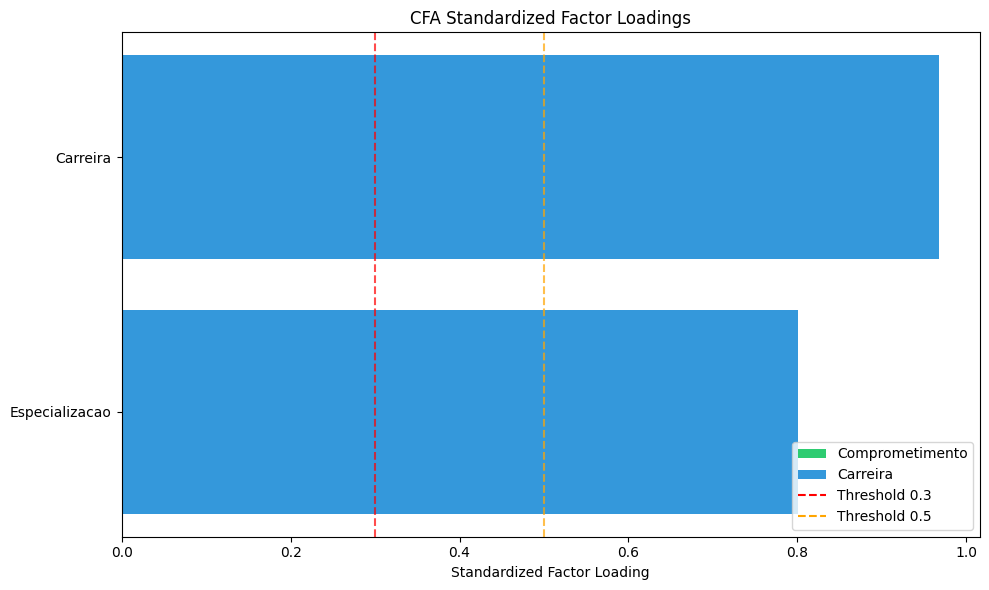

In [9]:
if SEMOPY_AVAILABLE:
    # Get STANDARDIZED estimates (like lavaan's summary with standardized=TRUE)
    # This gives the Std.all column equivalent
    estimates_std = model.inspect(std_est=True)
    # print("\n--- Standardized Estimates (equivalent to lavaan Std.all) ---")
    # display(estimates_std)
    
    # Extract standardized factor loadings
    loadings = estimates_std[estimates_std['op'] == '~'].copy()
    loadings = loadings[['lval', 'rval', 'Est. Std', 'Std. Err', 'p-value']]
    loadings.columns = ['Factor', 'Variable', 'Std.Loading', 'SE', 'p-value']
    
    print("\n--- Standardized Factor Loadings ---")
    display(loadings)
    
    # Visualize standardized factor loadings
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['#2ecc71' if f == 'Especializacao' else '#3498db' for f in loadings['Factor']]
    bars = ax.barh(loadings['Variable'], loadings['Std.Loading'], color=colors)
    
    ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.7, label='Acceptable threshold (0.3)')
    ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, label='Good threshold (0.5)')
    
    ax.set_xlabel('Standardized Factor Loading')
    ax.set_title('CFA Standardized Factor Loadings')
    ax.legend()
    
    # Add factor labels
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2ecc71', label='Comprometimento'),
                       Patch(facecolor='#3498db', label='Carreira')]
    ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='red', linestyle='--', label='Threshold 0.3'),
                                          plt.Line2D([0], [0], color='orange', linestyle='--', label='Threshold 0.5')],
              loc='lower right')
    
    plt.tight_layout()
    plt.show()

In [10]:
# Exploratory Factor Analysis for comparison (2 factors)
print("=" * 60)
print("EXPLORATORY FACTOR ANALYSIS (for comparison)")
print("=" * 60)

fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(df_cfa_norm)

# Get loadings
loadings_efa = pd.DataFrame(
    fa.loadings_,
    index=df_cfa_norm.columns,
    columns=['Factor1 (Especializacao)', 'Factor2 (Carreira)']
)

print("\n--- EFA Factor Loadings (Varimax rotation) ---")
display(loadings_efa.round(3))

# Eigenvalues
eigenvalues, _ = fa.get_eigenvalues()
print(f"\n--- Eigenvalues ---")
print(f"Factor 1: {eigenvalues[0]:.3f}")
print(f"Factor 2: {eigenvalues[1]:.3f}")

# Variance explained
variance = fa.get_factor_variance()
print(f"\n--- Variance Explained ---")
print(f"Factor 1: {variance[1][0]*100:.1f}%")
print(f"Factor 2: {variance[1][1]*100:.1f}%")
print(f"Total: {sum(variance[1])*100:.1f}%")

EXPLORATORY FACTOR ANALYSIS (for comparison)

--- EFA Factor Loadings (Varimax rotation) ---


,Factor1 (Especializacao),Factor2 (Carreira)
TempoAtuacao,0.627,0.256
Relatoria,0.345,0.734
PresidenciaComissao,0.244,0.464
FidelidadeGerais,0.735,0.524



--- Eigenvalues ---
Factor 1: 2.401
Factor 2: 0.753

--- Variance Explained ---
Factor 1: 27.8%
Factor 2: 27.4%
Total: 55.2%


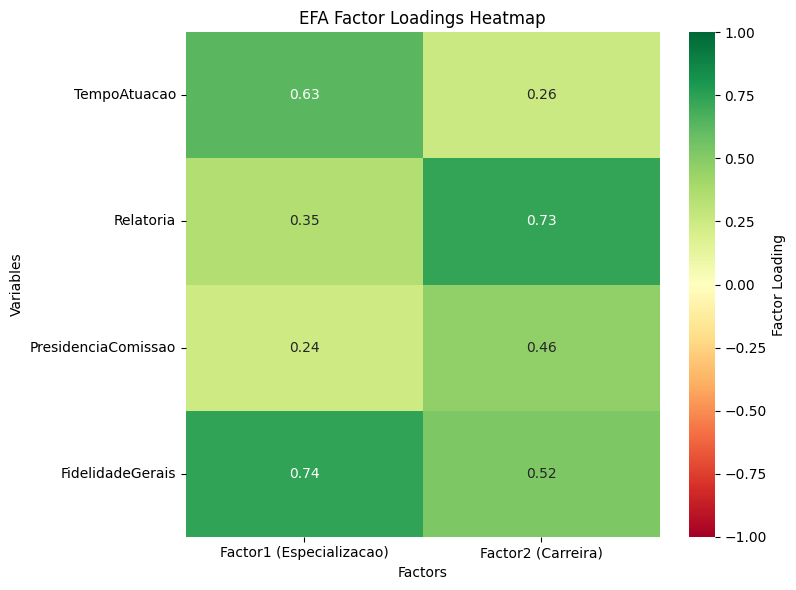


--- Variable-Factor Assignment Check ---
TempoAtuacao: Expected=Carreira, Highest loading on Factor1 (Especializacao) (0.627) ✗
Relatoria: Expected=Especializacao, Highest loading on Factor2 (Carreira) (0.734) ✗
PresidenciaComissao: Expected=Especializacao, Highest loading on Factor2 (Carreira) (0.464) ✗
FidelidadeGerais: Expected=Carreira, Highest loading on Factor1 (Especializacao) (0.735) ✗


In [11]:
# Visualize EFA loadings heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(loadings_efa, annot=True, cmap='RdYlGn', center=0, 
            vmin=-1, vmax=1, fmt='.2f', ax=ax,
            cbar_kws={'label': 'Factor Loading'})

ax.set_title('EFA Factor Loadings Heatmap')
ax.set_ylabel('Variables')
ax.set_xlabel('Factors')

plt.tight_layout()
plt.show()

# Check if variables load on expected factors
print("\n--- Variable-Factor Assignment Check ---")
for var in df_cfa_norm.columns:
    expected = 'Especializacao' if var in ['Mesa', 'PosicaoLider', 'PresidenciaComissao', 'Relatoria'] else 'Carreira'
    actual_loadings = loadings_efa.loc[var]
    max_factor = actual_loadings.abs().idxmax()
    max_loading = actual_loadings.abs().max()
    status = "✓" if expected in max_factor else "✗"
    print(f"{var}: Expected={expected}, Highest loading on {max_factor} ({max_loading:.3f}) {status}")

## 2. Sensitivity Analysis of Weights

Comparing three weighting schemes:
1. **No weights (equal weights = 1)** - All variables contribute equally
2. **Theoretical weights** - Based on expert judgment (5, 4, 3, 2, 1, 1, 1)
3. **Factor analysis weights** - Derived from factor loadings

We use Pearson and Spearman correlation of rankings to assess how sensitive the index is to different weight choices.

In [12]:
def calculate_ipp(df, var_cols, weights, var_dimensions):
    """
    Calculate IPP with given weights.
    
    Parameters:
    -----------
    df : DataFrame with IPP variables
    var_cols : list of variable column names
    weights : dict mapping variable names to weights
    var_dimensions : dict mapping variable names to dimensions
    
    Returns:
    --------
    Series with IPP values
    """
    df_calc = df[var_cols].copy()
    
    # # Normalize variables
    # for col in var_cols:
    #     df_calc[f"{col}_norm"] = min_max_normalize(df_calc[col])
    
    # Apply weights
    for col in var_cols:
        # df_calc[f"{col}_w"] = df_calc[f"{col}_norm"] * weights.get(col, 1)
        df_calc[f"{col}_w"] = df_calc[f"{col}"] * weights.get(col, 1)
    
    # Calculate dimensions
    esp_cols = [f"{col}_w" for col in var_cols if var_dimensions[col] == 'Especializacao']
    car_cols = [f"{col}_w" for col in var_cols if var_dimensions[col] == 'Carreira']
    
    df_calc['dim_especializacao'] = df_calc[esp_cols].sum(axis=1)
    df_calc['dim_carreira'] = df_calc[car_cols].sum(axis=1)
    
    # Normalize dimensions
    df_calc['dim_especializacao_norm'] = min_max_normalize(df_calc['dim_especializacao'])
    df_calc['dim_carreira_norm'] = min_max_normalize(df_calc['dim_carreira'])
    
    # Calculate IPP
    ipp = (df_calc['dim_especializacao_norm'] + df_calc['dim_carreira_norm']) / 2
    
    return ipp

In [13]:
# Define weight schemes

# 1. No weights (equal weights)
equal_weights = {col: 1 for col in var_cols}

# 2. Theoretical weights (from documentation)
# Already defined above as theoretical_weights

# 3. Factor analysis weights (based on EFA loadings)
# Use absolute factor loadings as weights, normalized
fa_loadings_abs = loadings_efa.abs()
fa_weights = {}
for col in var_cols:
    var_label = var_labels[col]
    expected_dim = var_dimensions[col]
    factor_col = 'Factor1 (Especializacao)' if expected_dim == 'Especializacao' else 'Factor2 (Carreira)'
    # Use the loading on the expected factor as weight
    fa_weights[col] = fa_loadings_abs.loc[var_label, factor_col]

# Normalize FA weights to have similar scale as theoretical
max_theoretical = max(theoretical_weights.values())
max_fa = max(fa_weights.values())
fa_weights_scaled = {k: v * (max_theoretical / max_fa) for k, v in fa_weights.items()}

print("Weight Schemes Comparison:")
print("=" * 70)
print(f"{'Variable':<30} {'Equal':>10} {'Theoretical':>12} {'FA-based':>12}")
print("-" * 70)
for col in var_cols:
    print(f"{var_labels[col]:<30} {equal_weights[col]:>10.2f} {theoretical_weights[col]:>12.2f} {fa_weights_scaled[col]:>12.2f}")
print("=" * 70)

Weight Schemes Comparison:
Variable                            Equal  Theoretical     FA-based
----------------------------------------------------------------------
TempoAtuacao                         1.00         1.00         2.45
Relatoria                            1.00         2.00         3.30
PresidenciaComissao                  1.00         3.00         2.33
FidelidadeGerais                     1.00         1.00         5.00


In [14]:
# Calculate IPP with each weight scheme
df_sensitivity = df[['id', 'idLegislatura'] + var_cols].copy()

df_sensitivity['ipp_equal'] = calculate_ipp(df, var_cols, equal_weights, var_dimensions)
df_sensitivity['ipp_theoretical'] = calculate_ipp(df, var_cols, theoretical_weights, var_dimensions)
df_sensitivity['ipp_fa'] = calculate_ipp(df, var_cols, fa_weights_scaled, var_dimensions)

# Calculate rankings
df_sensitivity['rank_equal'] = df_sensitivity['ipp_equal'].rank(ascending=False)
df_sensitivity['rank_theoretical'] = df_sensitivity['ipp_theoretical'].rank(ascending=False)
df_sensitivity['rank_fa'] = df_sensitivity['ipp_fa'].rank(ascending=False)

print("IPP Descriptive Statistics by Weight Scheme:")
df_sensitivity[['ipp_equal', 'ipp_theoretical', 'ipp_fa']].describe().round(4)

IPP Descriptive Statistics by Weight Scheme:


,ipp_equal,ipp_theoretical,ipp_fa
count,6250.0000,6250.0000,6250.0000
mean,0.3253,0.3104,0.2883
std,0.1357,0.1276,0.1522
min,0.0000,0.0000,0.0000
25%,0.2120,0.2056,0.1590
50%,0.3043,0.2862,0.2676
75%,0.4066,0.3828,0.3836
max,0.9165,0.9165,0.8956


In [15]:
# Correlation analysis between weight schemes
print("=" * 60)
print("CORRELATION ANALYSIS - IPP VALUES")
print("=" * 60)

# Pearson correlation of IPP values
ipp_cols = ['ipp_equal', 'ipp_theoretical', 'ipp_fa']
ipp_labels = ['Equal Weights', 'Theoretical Weights', 'FA Weights']

print("\n--- Pearson Correlation of IPP Values ---")
corr_ipp = df_sensitivity[ipp_cols].corr()
corr_ipp.index = ipp_labels
corr_ipp.columns = ipp_labels
display(corr_ipp.round(4))

# Pearson correlation of rankings
print("\n--- Pearson Correlation of Rankings ---")
rank_cols = ['rank_equal', 'rank_theoretical', 'rank_fa']
corr_rank = df_sensitivity[rank_cols].corr()
corr_rank.index = ipp_labels
corr_rank.columns = ipp_labels
display(corr_rank.round(4))

# Spearman correlation (rank correlation)
print("\n--- Spearman Rank Correlation ---")
spearman_matrix = pd.DataFrame(index=ipp_labels, columns=ipp_labels, dtype=float)
for i, col1 in enumerate(ipp_cols):
    for j, col2 in enumerate(ipp_cols):
        rho, _ = spearmanr(df_sensitivity[col1], df_sensitivity[col2])
        spearman_matrix.iloc[i, j] = rho
display(spearman_matrix.round(4))

CORRELATION ANALYSIS - IPP VALUES

--- Pearson Correlation of IPP Values ---


,Equal Weights,Theoretical Weights,FA Weights
Equal Weights,1.0000,0.9973,0.9961
Theoretical Weights,0.9973,1.0000,0.9891
FA Weights,0.9961,0.9891,1.0000



--- Pearson Correlation of Rankings ---


,Equal Weights,Theoretical Weights,FA Weights
Equal Weights,1.0000,0.9977,0.9962
Theoretical Weights,0.9977,1.0000,0.9915
FA Weights,0.9962,0.9915,1.0000



--- Spearman Rank Correlation ---


,Equal Weights,Theoretical Weights,FA Weights
Equal Weights,1.0000,0.9977,0.9962
Theoretical Weights,0.9977,1.0000,0.9915
FA Weights,0.9962,0.9915,1.0000


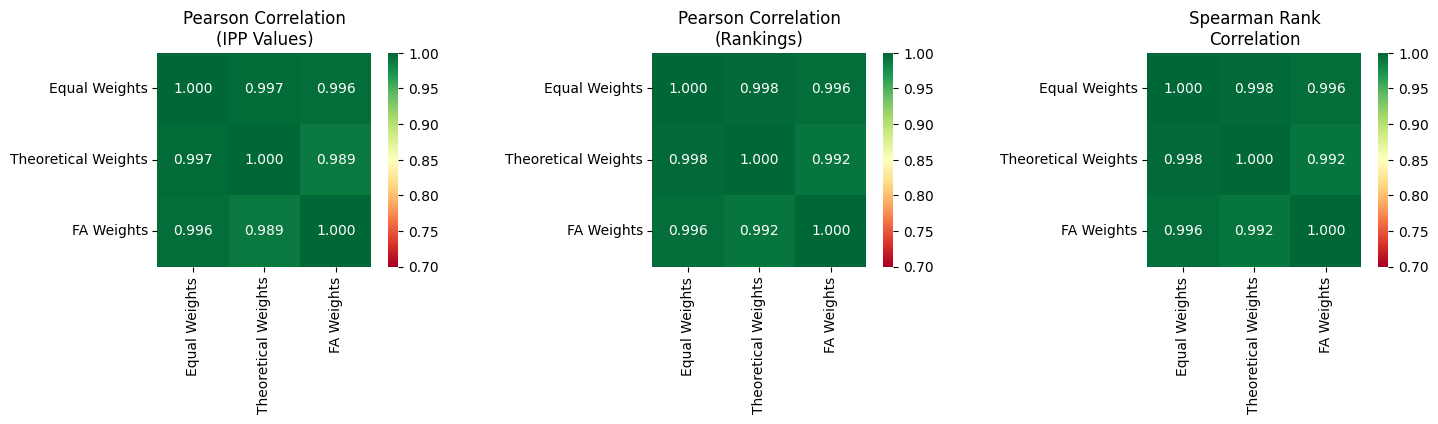

In [16]:
# Visualize correlations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Heatmap of Pearson correlations
sns.heatmap(corr_ipp, annot=True, cmap='RdYlGn', vmin=0.7, vmax=1, 
            fmt='.3f', ax=axes[0], square=True)
axes[0].set_title('Pearson Correlation\n(IPP Values)')

# Heatmap of Rank correlations
sns.heatmap(corr_rank, annot=True, cmap='RdYlGn', vmin=0.7, vmax=1, 
            fmt='.3f', ax=axes[1], square=True)
axes[1].set_title('Pearson Correlation\n(Rankings)')

# Heatmap of Spearman correlations
sns.heatmap(spearman_matrix.astype(float), annot=True, cmap='RdYlGn', vmin=0.7, vmax=1, 
            fmt='.3f', ax=axes[2], square=True)
axes[2].set_title('Spearman Rank\nCorrelation')

plt.tight_layout()
plt.savefig('../../docs/figures/ipp_sensitivity_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

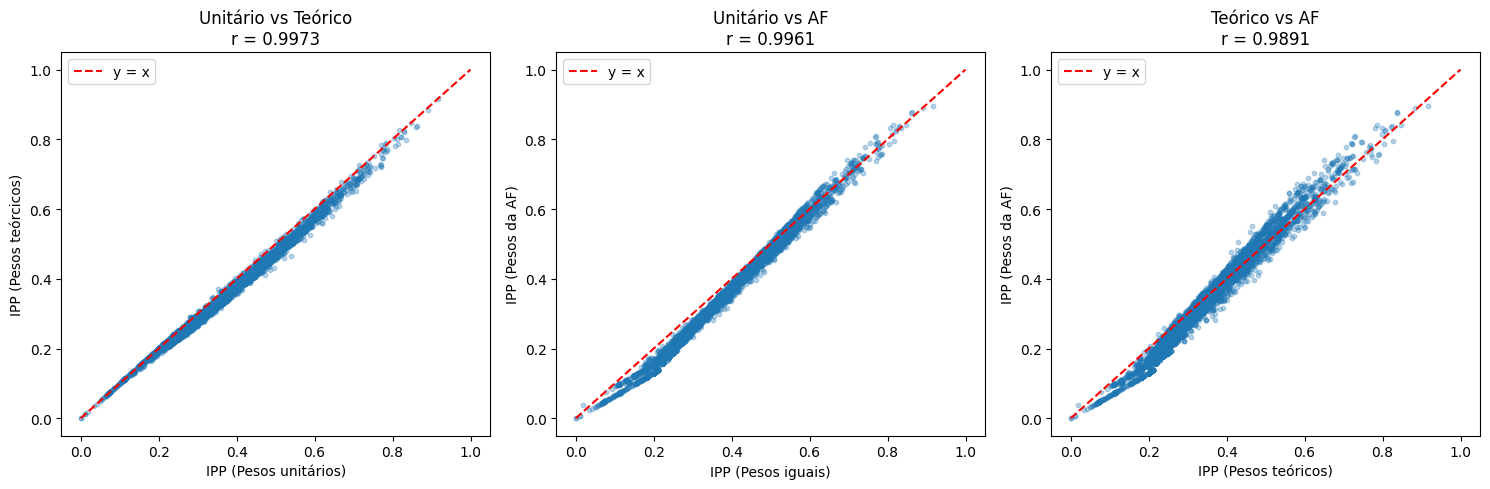

In [17]:
# Scatter plots comparing weight schemes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Equal vs Theoretical
axes[0].scatter(df_sensitivity['ipp_equal'], df_sensitivity['ipp_theoretical'], 
                alpha=0.3, s=10)
axes[0].plot([0, 1], [0, 1], 'r--', label='y = x')
r_val, _ = pearsonr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_theoretical'])
axes[0].set_xlabel('IPP (Pesos unitários)')
axes[0].set_ylabel('IPP (Pesos teórcicos)')
axes[0].set_title(f'Unitário vs Teórico\nr = {r_val:.4f}')
axes[0].legend()

# Equal vs FA
axes[1].scatter(df_sensitivity['ipp_equal'], df_sensitivity['ipp_fa'], 
                alpha=0.3, s=10)
axes[1].plot([0, 1], [0, 1], 'r--', label='y = x')
r_val, _ = pearsonr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_fa'])
axes[1].set_xlabel('IPP (Pesos iguais)')
axes[1].set_ylabel('IPP (Pesos da AF)')
axes[1].set_title(f'Unitário vs AF\nr = {r_val:.4f}')
axes[1].legend()

# Theoretical vs FA
axes[2].scatter(df_sensitivity['ipp_theoretical'], df_sensitivity['ipp_fa'], 
                alpha=0.3, s=10)
axes[2].plot([0, 1], [0, 1], 'r--', label='y = x')
r_val, _ = pearsonr(df_sensitivity['ipp_theoretical'], df_sensitivity['ipp_fa'])
axes[2].set_xlabel('IPP (Pesos teóricos)')
axes[2].set_ylabel('IPP (Pesos da AF)')
axes[2].set_title(f'Teórico vs AF\nr = {r_val:.4f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('../../docs/figures/ipp_sensitivity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 Cronbach's Alpha - Internal Consistency

Cronbach's Alpha measures the internal consistency (reliability) of the IPP scale. We calculate it for:
1. **Full Scale** - All IPP indicators together
2. **Especialização Legislativa** - Legislative specialization dimension
3. **Carreira Parlamentar** - Parliamentary career dimension

Interpretation thresholds:
- α ≥ 0.9: Excellent
- 0.8 ≤ α < 0.9: Good
- 0.7 ≤ α < 0.8: Acceptable
- 0.6 ≤ α < 0.7: Questionable
- α < 0.6: Poor

In [18]:
# Cronbach's Alpha calculation
def cronbach_alpha(data):
    """
    Calculate Cronbach's Alpha for internal consistency.
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with items as columns
        
    Returns:
    --------
    float : Cronbach's alpha coefficient
    """
    # Number of items
    k = data.shape[1]
    
    # Variance of each item
    item_variances = data.var(axis=0, ddof=1)
    
    # Total score variance
    total_scores = data.sum(axis=1)
    total_variance = total_scores.var(ddof=1)
    
    # Cronbach's Alpha formula
    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
    
    return alpha

def interpret_alpha(alpha):
    """Interpret Cronbach's Alpha value"""
    if alpha >= 0.9:
        return "Excellent"
    elif alpha >= 0.8:
        return "Good"
    elif alpha >= 0.7:
        return "Acceptable"
    elif alpha >= 0.6:
        return "Questionable"
    else:
        return "Poor"

# Define dimension groupings
especializacao_vars = [v[0] for v in ipp_vars if v[2] == "Especializacao"]
carreira_vars = [v[0] for v in ipp_vars if v[2] == "Carreira"]

print("=" * 60)
print("CRONBACH'S ALPHA - INTERNAL CONSISTENCY")
print("=" * 60)

# Full scale
alpha_full = cronbach_alpha(df[var_cols])
print(f"\n1. FULL SCALE (all {len(var_cols)} items)")
print(f"   Items: {[var_labels[v] for v in var_cols]}")
print(f"   Cronbach's Alpha: {alpha_full:.4f}")
print(f"   Interpretation: {interpret_alpha(alpha_full)}")

# Especialização Legislativa dimension
if len(especializacao_vars) >= 2:
    alpha_espec = cronbach_alpha(df[especializacao_vars])
    print(f"\n2. ESPECIALIZAÇÃO LEGISLATIVA ({len(especializacao_vars)} items)")
    print(f"   Items: {[var_labels[v] for v in especializacao_vars]}")
    print(f"   Cronbach's Alpha: {alpha_espec:.4f}")
    print(f"   Interpretation: {interpret_alpha(alpha_espec)}")
else:
    alpha_espec = None
    print(f"\n2. ESPECIALIZAÇÃO LEGISLATIVA - Not enough items (need >= 2)")

# Carreira Parlamentar dimension
if len(carreira_vars) >= 2:
    alpha_carreira = cronbach_alpha(df[carreira_vars])
    print(f"\n3. CARREIRA PARLAMENTAR ({len(carreira_vars)} items)")
    print(f"   Items: {[var_labels[v] for v in carreira_vars]}")
    print(f"   Cronbach's Alpha: {alpha_carreira:.4f}")
    print(f"   Interpretation: {interpret_alpha(alpha_carreira)}")
else:
    alpha_carreira = None
    print(f"\n3. CARREIRA PARLAMENTAR - Not enough items (need >= 2)")

print("\n" + "=" * 60)

CRONBACH'S ALPHA - INTERNAL CONSISTENCY

1. FULL SCALE (all 4 items)
   Items: ['TempoAtuacao', 'Relatoria', 'PresidenciaComissao', 'FidelidadeGerais']
   Cronbach's Alpha: 0.7629
   Interpretation: Acceptable

2. ESPECIALIZAÇÃO LEGISLATIVA (2 items)
   Items: ['Relatoria', 'PresidenciaComissao']
   Cronbach's Alpha: 0.5556
   Interpretation: Poor

3. CARREIRA PARLAMENTAR (2 items)
   Items: ['TempoAtuacao', 'FidelidadeGerais']
   Cronbach's Alpha: 0.6554
   Interpretation: Questionable



In [19]:
# Item-level analysis: Item-total correlations and Alpha if item deleted
print("=" * 70)
print("ITEM-LEVEL RELIABILITY ANALYSIS")
print("=" * 70)

results = []
total_score = df[var_cols].sum(axis=1)

for var in var_cols:
    # Item-total correlation (corrected: correlation with sum of other items)
    other_items = [v for v in var_cols if v != var]
    other_total = df[other_items].sum(axis=1)
    r_corrected, _ = pearsonr(df[var], other_total)
    
    # Alpha if item deleted
    if len(other_items) >= 2:
        alpha_if_deleted = cronbach_alpha(df[other_items])
    else:
        alpha_if_deleted = np.nan
    
    results.append({
        'Item': var_labels[var],
        'Variable': var,
        'Dimension': var_dimensions[var],
        'Corrected Item-Total r': r_corrected,
        'Alpha if Deleted': alpha_if_deleted
    })

df_reliability = pd.DataFrame(results)
print("\n")
print(df_reliability[['Item', 'Dimension', 'Corrected Item-Total r', 'Alpha if Deleted']].to_string(index=False))
print(f"\nCurrent Full Scale Alpha: {alpha_full:.4f}")
print("\nNote: Items with 'Alpha if Deleted' > Current Alpha may be reducing reliability.")

ITEM-LEVEL RELIABILITY ANALYSIS


               Item      Dimension  Corrected Item-Total r  Alpha if Deleted
       TempoAtuacao       Carreira                0.538381          0.741731
          Relatoria Especializacao                0.644771          0.665570
PresidenciaComissao Especializacao                0.461920          0.758058
   FidelidadeGerais       Carreira                0.725330          0.608706

Current Full Scale Alpha: 0.7629

Note: Items with 'Alpha if Deleted' > Current Alpha may be reducing reliability.


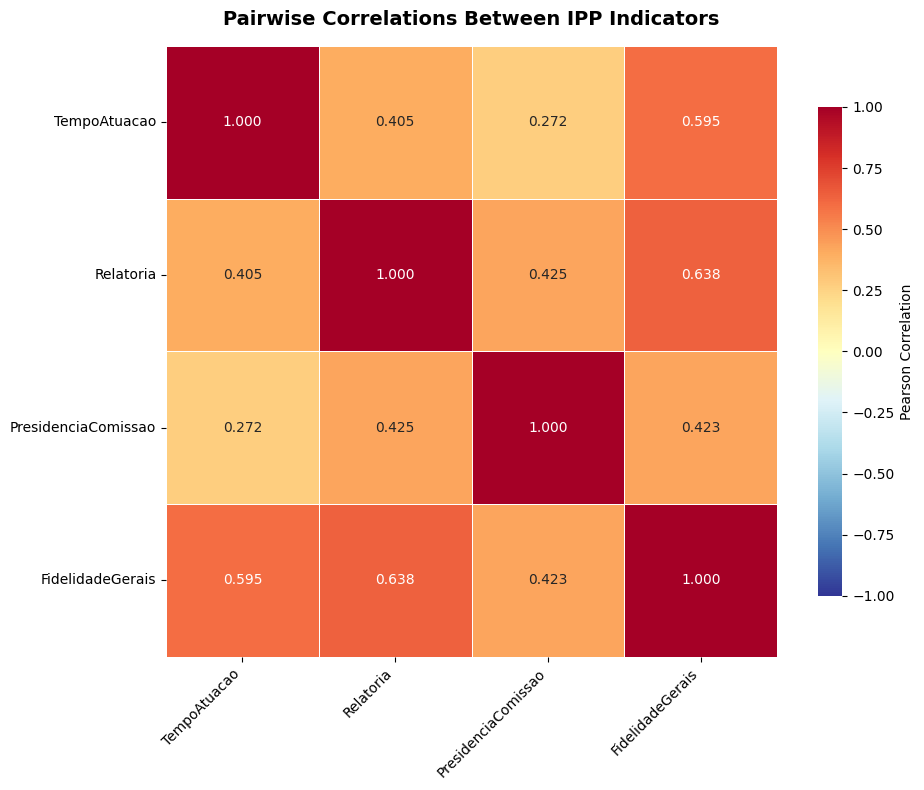


Correlation Matrix:
                     TempoAtuacao  Relatoria  PresidenciaComissao  FidelidadeGerais
TempoAtuacao                1.000      0.405                0.272             0.595
Relatoria                   0.405      1.000                0.425             0.638
PresidenciaComissao         0.272      0.425                1.000             0.423
FidelidadeGerais            0.595      0.638                0.423             1.000


In [20]:
# Pairwise correlations heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate correlation matrix with nice labels
corr_data = df[var_cols].copy()
corr_data.columns = [var_labels[v] for v in var_cols]
corr_matrix = corr_data.corr()

# Create heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Upper triangle mask
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.3f', 
            cmap='RdYlBu_r',
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            ax=ax)

ax.set_title('Pairwise Correlations Between IPP Indicators', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../../docs/figures/ipp_correlations_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print correlation matrix
print("\nCorrelation Matrix:")
print(corr_matrix.round(3).to_string())

### McDonald's Omega (ω) - CFA-Based Reliability

McDonald's Omega is a model-based reliability estimate computed from CFA standardized factor loadings. Unlike Cronbach's Alpha, it does not assume tau-equivalence (equal factor loadings), providing a more accurate estimate when items have different relationships with the underlying construct.

**Formula:** ωt = (Σλ)² / [(Σλ)² + Σθ²]

Where:
- λ = standardized factor loadings from CFA
- θ² = error variances (1 - λ² for standardized loadings)

**Interpretation:**
- ω ≥ 0.70: Adequate reliability
- ω ≥ 0.80: Good reliability
- ω ≥ 0.90: Excellent reliability

In [21]:
# McDonald's Omega calculation using CFA-based approach
# Formula: ωt = (Σλ)² / [(Σλ)² + Σθ²]
# where λ = standardized factor loadings, θ² = error variances (1 - λ²)

def mcdonalds_omega_from_loadings(std_loadings):
    """
    Calculate McDonald's Omega Total from standardized factor loadings.
    Correct for unidimensional scales.
    
    Parameters:
    -----------
    std_loadings : array-like
        Standardized factor loadings from CFA
        
    Returns:
    --------
    tuple : (omega_total, error_variances)
    """
    std_loadings = np.array(std_loadings).astype(float)
    
    # Sum of loadings
    sum_loadings = std_loadings.sum()
    sum_loadings_sq = sum_loadings ** 2
    
    # Error variances: θ² = 1 - λ² (for standardized loadings)
    error_variances = 1 - std_loadings ** 2
    sum_error_variances = error_variances.sum()
    
    # Omega total: ωt = (Σλ)² / [(Σλ)² + Σθ²]
    omega_total = sum_loadings_sq / (sum_loadings_sq + sum_error_variances)
    
    return omega_total, error_variances

print("=" * 60)
print("McDONALD'S OMEGA (ω) - CFA-BASED RELIABILITY")
print("=" * 60)

# Initialize omega variables
omega_total_2f = None
omega_espec = None
omega_carreira = None

# Check if CFA model exists
cfa_model_available = SEMOPY_AVAILABLE and 'model' in dir() and model is not None

if cfa_model_available:
    try:
        # Extract standardized loadings from CFA model
        estimates_std = model.inspect(std_est=True)
        cfa_loadings = estimates_std[estimates_std['op'] == '~'].copy()
        
        print("\n1. CFA-BASED OMEGA (Using confirmed factor structure)")
        print("-" * 50)
        
        # Separate loadings by factor (using rval which contains factor name)
        espec_loadings_df = cfa_loadings[cfa_loadings['rval'] == 'Especializacao']
        carreira_loadings_df = cfa_loadings[cfa_loadings['rval'] == 'Carreira']
        
        espec_loadings = espec_loadings_df['Est. Std'].values.astype(float)
        carreira_loadings = carreira_loadings_df['Est. Std'].values.astype(float)
        
        # Calculate Omega for Especialização dimension
        if len(espec_loadings) >= 2:
            omega_espec, errors_espec = mcdonalds_omega_from_loadings(espec_loadings)
            print(f"\n   ESPECIALIZAÇÃO LEGISLATIVA ({len(espec_loadings)} items)")
            print(f"   Omega Total (ωt): {omega_espec:.4f} ({interpret_alpha(omega_espec)})")
            print(f"   CFA Loadings & Error Variances:")
            for i, row in enumerate(espec_loadings_df.itertuples()):
                var_name = row.lval
                label = var_labels.get(var_name, var_name)
                print(f"      {label}: λ = {espec_loadings[i]:.4f}, θ² = {errors_espec[i]:.4f}")
        else:
            print(f"\n   ESPECIALIZAÇÃO LEGISLATIVA - Not enough items (need >= 2)")
        
        # Calculate Omega for Carreira dimension
        if len(carreira_loadings) >= 2:
            omega_carreira, errors_carreira = mcdonalds_omega_from_loadings(carreira_loadings)
            print(f"\n   CARREIRA PARLAMENTAR ({len(carreira_loadings)} items)")
            print(f"   Omega Total (ωt): {omega_carreira:.4f} ({interpret_alpha(omega_carreira)})")
            print(f"   CFA Loadings & Error Variances:")
            for i, row in enumerate(carreira_loadings_df.itertuples()):
                var_name = row.lval
                label = var_labels.get(var_name, var_name)
                print(f"      {label}: λ = {carreira_loadings[i]:.4f}, θ² = {errors_carreira[i]:.4f}")
        else:
            print(f"\n   CARREIRA PARLAMENTAR - Not enough items (need >= 2)")
        
        # Full scale omega: use simple formula ignoring factor correlation
        # (Σ_all λ)² / [(Σ_all λ)² + Σθ²]
        # This is appropriate when reporting subscale omega is primary
        all_loadings = np.concatenate([espec_loadings, carreira_loadings])
        all_errors = np.concatenate([errors_espec, errors_carreira])
        
        sum_all = all_loadings.sum()
        omega_total_2f = (sum_all ** 2) / (sum_all ** 2 + all_errors.sum())
        
        print(f"\n   FULL SCALE (composite)")
        print(f"   Omega Total (ωt): {omega_total_2f:.4f} ({interpret_alpha(omega_total_2f)})")
        print(f"   Note: For multidimensional scales, subscale ω is more interpretable.")
        print(f"         Full-scale ω assumes unidimensionality (use with caution).")
        
    except Exception as e:
        print(f"\n   Error extracting CFA loadings: {e}")
        cfa_model_available = False

if not cfa_model_available:
    print("\n   CFA model not available. Using EFA-based approximation.")
    print("   (For accurate omega, run CFA cells first or use lavaan in R)")
    
    # Fallback to EFA-based calculation
    from factor_analyzer import FactorAnalyzer
    
    for dim_name, dim_vars in [("ESPECIALIZAÇÃO LEGISLATIVA", especializacao_vars), 
                                ("CARREIRA PARLAMENTAR", carreira_vars)]:
        if len(dim_vars) >= 2:
            try:
                fa = FactorAnalyzer(n_factors=1, method='ml')
                fa.fit(df[dim_vars])
                loadings_1f = fa.loadings_.flatten()
                uniquenesses = fa.get_uniquenesses()
                
                # ωt = (Σλ)² / [(Σλ)² + Σθ²]
                sum_l = loadings_1f.sum()
                omega = (sum_l ** 2) / (sum_l ** 2 + uniquenesses.sum())
                
                print(f"\n   {dim_name} ({len(dim_vars)} items)")
                print(f"   Omega Total (ωt): {omega:.4f} ({interpret_alpha(omega)})")
                print(f"   Loadings: {loadings_1f.round(4)}")
                
                if "ESPECIALIZAÇÃO" in dim_name:
                    omega_espec = omega
                else:
                    omega_carreira = omega
            except Exception as e:
                print(f"\n   {dim_name} - Error: {e}")

# Comparison with Cronbach's Alpha
print(f"\n" + "=" * 60)
print("COMPARISON: Cronbach's Alpha vs McDonald's Omega")
print("=" * 60)

print(f"\n   {'Scale':<30} {'Alpha':>10} {'Omega':>10} {'Diff':>10}")
print(f"   {'-'*60}")

# Especialização dimension
if alpha_espec is not None:
    print(f"   {'Especialização Legislativa':<30} {alpha_espec:>10.4f}", end="")
    if omega_espec is not None:
        diff_espec = omega_espec - alpha_espec
        print(f" {omega_espec:>10.4f} {diff_espec:>+10.4f}")
    else:
        print(f" {'N/A':>10} {'N/A':>10}")

# Carreira dimension
if alpha_carreira is not None:
    print(f"   {'Carreira Parlamentar':<30} {alpha_carreira:>10.4f}", end="")
    if omega_carreira is not None:
        diff_carreira = omega_carreira - alpha_carreira
        print(f" {omega_carreira:>10.4f} {diff_carreira:>+10.4f}")
    else:
        print(f" {'N/A':>10} {'N/A':>10}")

# Full scale (with caveat)
print(f"   {'Full Scale*':<30} {alpha_full:>10.4f}", end="")
if omega_total_2f is not None:
    diff_full = omega_total_2f - alpha_full
    print(f" {omega_total_2f:>10.4f} {diff_full:>+10.4f}")
else:
    print(f" {'N/A':>10} {'N/A':>10}")

print(f"\n   Formula: ωt = (Σλ)² / [(Σλ)² + Σθ²]")
print(f"   * Full-scale ω assumes unidimensionality; subscale ω more interpretable")
print(f"\n   Interpretation:")
print(f"   - |diff| < 0.05: Tau-equivalence holds, Alpha is adequate")
print(f"   - ω > α: Alpha underestimates (loadings vary substantially)")
print(f"   - ω < α: Alpha may overestimate (negative residual covariances)")
print(f"   - Threshold: ω ≥ 0.70 adequate, ω ≥ 0.80 good")

print("\n" + "=" * 60)

McDONALD'S OMEGA (ω) - CFA-BASED RELIABILITY

1. CFA-BASED OMEGA (Using confirmed factor structure)
--------------------------------------------------

   ESPECIALIZAÇÃO LEGISLATIVA (2 items)
   Omega Total (ωt): 0.6222 (Questionable)
   CFA Loadings & Error Variances:
      Relatoria: λ = 0.8007, θ² = 0.3588
      PresidenciaComissao: λ = 0.5310, θ² = 0.7181

   CARREIRA PARLAMENTAR (2 items)
   Omega Total (ωt): 0.7852 (Acceptable)
   CFA Loadings & Error Variances:
      TempoAtuacao: λ = 0.6151, θ² = 0.6216
      FidelidadeGerais: λ = 0.9677, θ² = 0.0636

   FULL SCALE (composite)
   Omega Total (ωt): 0.8282 (Good)
   Note: For multidimensional scales, subscale ω is more interpretable.
         Full-scale ω assumes unidimensionality (use with caution).

COMPARISON: Cronbach's Alpha vs McDonald's Omega

   Scale                               Alpha      Omega       Diff
   ------------------------------------------------------------
   Especialização Legislativa         0.5556     0.

In [22]:
# Analyze ranking stability - Top N analysis
print("=" * 60)
print("RANKING STABILITY ANALYSIS")
print("=" * 60)

for top_n in [10, 50, 100, 500]:
    print(f"\n--- Top {top_n} Overlap ---")
    
    top_equal = set(df_sensitivity.nsmallest(top_n, 'rank_equal')['id'])
    top_theoretical = set(df_sensitivity.nsmallest(top_n, 'rank_theoretical')['id'])
    top_fa = set(df_sensitivity.nsmallest(top_n, 'rank_fa')['id'])
    
    overlap_eq_th = len(top_equal & top_theoretical) / top_n * 100
    overlap_eq_fa = len(top_equal & top_fa) / top_n * 100
    overlap_th_fa = len(top_theoretical & top_fa) / top_n * 100
    overlap_all = len(top_equal & top_theoretical & top_fa) / top_n * 100
    
    print(f"  Equal ∩ Theoretical: {overlap_eq_th:.1f}%")
    print(f"  Equal ∩ FA: {overlap_eq_fa:.1f}%")
    print(f"  Theoretical ∩ FA: {overlap_th_fa:.1f}%")
    print(f"  All three: {overlap_all:.1f}%")

RANKING STABILITY ANALYSIS

--- Top 10 Overlap ---
  Equal ∩ Theoretical: 60.0%
  Equal ∩ FA: 60.0%
  Theoretical ∩ FA: 50.0%
  All three: 50.0%

--- Top 50 Overlap ---
  Equal ∩ Theoretical: 56.0%
  Equal ∩ FA: 54.0%
  Theoretical ∩ FA: 50.0%
  All three: 50.0%

--- Top 100 Overlap ---
  Equal ∩ Theoretical: 55.0%
  Equal ∩ FA: 52.0%
  Theoretical ∩ FA: 51.0%
  All three: 51.0%

--- Top 500 Overlap ---
  Equal ∩ Theoretical: 46.0%
  Equal ∩ FA: 45.4%
  Theoretical ∩ FA: 43.4%
  All three: 43.4%


In [23]:
# Calculate average rank change
df_sensitivity['rank_diff_eq_th'] = abs(df_sensitivity['rank_equal'] - df_sensitivity['rank_theoretical'])
df_sensitivity['rank_diff_eq_fa'] = abs(df_sensitivity['rank_equal'] - df_sensitivity['rank_fa'])
df_sensitivity['rank_diff_th_fa'] = abs(df_sensitivity['rank_theoretical'] - df_sensitivity['rank_fa'])

print("\n" + "=" * 60)
print("RANK CHANGE STATISTICS")
print("=" * 60)
print(f"\nMean Absolute Rank Change:")
print(f"  Equal vs Theoretical: {df_sensitivity['rank_diff_eq_th'].mean():.2f} (±{df_sensitivity['rank_diff_eq_th'].std():.2f})")
print(f"  Equal vs FA: {df_sensitivity['rank_diff_eq_fa'].mean():.2f} (±{df_sensitivity['rank_diff_eq_fa'].std():.2f})")
print(f"  Theoretical vs FA: {df_sensitivity['rank_diff_th_fa'].mean():.2f} (±{df_sensitivity['rank_diff_th_fa'].std():.2f})")

print(f"\nMedian Absolute Rank Change:")
print(f"  Equal vs Theoretical: {df_sensitivity['rank_diff_eq_th'].median():.2f}")
print(f"  Equal vs FA: {df_sensitivity['rank_diff_eq_fa'].median():.2f}")
print(f"  Theoretical vs FA: {df_sensitivity['rank_diff_th_fa'].median():.2f}")


RANK CHANGE STATISTICS

Mean Absolute Rank Change:
  Equal vs Theoretical: 83.00 (±88.32)
  Equal vs FA: 97.23 (±123.74)
  Theoretical vs FA: 165.00 (±167.14)

Median Absolute Rank Change:
  Equal vs Theoretical: 55.50
  Equal vs FA: 71.00
  Theoretical vs FA: 121.00


## 3. Summary of Validation Results

In [24]:
# Summary statistics
print("=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

print("\n1. CONFIRMATORY FACTOR ANALYSIS")
print("-" * 40)
print("   - Two-factor structure tested")
print("   - See factor loadings above for model fit assessment")

print("\n2. SENSITIVITY ANALYSIS")
print("-" * 40)
r_eq_th, _ = pearsonr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_theoretical'])
r_eq_fa, _ = pearsonr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_fa'])
r_th_fa, _ = pearsonr(df_sensitivity['ipp_theoretical'], df_sensitivity['ipp_fa'])
rho_eq_th, _ = spearmanr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_theoretical'])
rho_eq_fa, _ = spearmanr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_fa'])
rho_th_fa, _ = spearmanr(df_sensitivity['ipp_theoretical'], df_sensitivity['ipp_fa'])

print(f"   Pearson correlations:")
print(f"   - Equal vs Theoretical: r = {r_eq_th:.4f}")
print(f"   - Equal vs FA weights:  r = {r_eq_fa:.4f}")
print(f"   - Theoretical vs FA:    r = {r_th_fa:.4f}")
print(f"\n   Spearman rank correlations:")
print(f"   - Equal vs Theoretical: ρ = {rho_eq_th:.4f}")
print(f"   - Equal vs FA weights:  ρ = {rho_eq_fa:.4f}")
print(f"   - Theoretical vs FA:    ρ = {rho_th_fa:.4f}")

if min(rho_eq_th, rho_eq_fa, rho_th_fa) > 0.9:
    sens_conclusion = "LOW - Rankings are highly stable across weight schemes"
elif min(rho_eq_th, rho_eq_fa, rho_th_fa) > 0.8:
    sens_conclusion = "MODERATE - Rankings are reasonably stable"
else:
    sens_conclusion = "HIGH - Rankings vary significantly with weights"
print(f"\n   Sensitivity: {sens_conclusion}")

print("\n3. CRONBACH'S ALPHA (Internal Consistency)")
print("-" * 40)
print(f"   Full Scale: α = {alpha_full:.4f} ({interpret_alpha(alpha_full)})")
if alpha_espec is not None:
    print(f"   Especialização Legislativa: α = {alpha_espec:.4f} ({interpret_alpha(alpha_espec)})")
if alpha_carreira is not None:
    print(f"   Carreira Parlamentar: α = {alpha_carreira:.4f} ({interpret_alpha(alpha_carreira)})")

print("\n4. McDONALD'S OMEGA (CFA-Based Reliability)")
print("-" * 40)
if omega_espec is not None:
    print(f"   Especialização Legislativa: ω = {omega_espec:.4f} ({interpret_alpha(omega_espec)})")
if omega_carreira is not None:
    print(f"   Carreira Parlamentar: ω = {omega_carreira:.4f} ({interpret_alpha(omega_carreira)})")
if omega_total_2f is not None:
    print(f"   Full Scale (2-factor): ω = {omega_total_2f:.4f} ({interpret_alpha(omega_total_2f)})")

print("\n" + "=" * 70)

VALIDATION SUMMARY

1. CONFIRMATORY FACTOR ANALYSIS
----------------------------------------
   - Two-factor structure tested
   - See factor loadings above for model fit assessment

2. SENSITIVITY ANALYSIS
----------------------------------------
   Pearson correlations:
   - Equal vs Theoretical: r = 0.9973
   - Equal vs FA weights:  r = 0.9961
   - Theoretical vs FA:    r = 0.9891

   Spearman rank correlations:
   - Equal vs Theoretical: ρ = 0.9977
   - Equal vs FA weights:  ρ = 0.9962
   - Theoretical vs FA:    ρ = 0.9915

   Sensitivity: LOW - Rankings are highly stable across weight schemes

3. CRONBACH'S ALPHA (Internal Consistency)
----------------------------------------
   Full Scale: α = 0.7629 (Acceptable)
   Especialização Legislativa: α = 0.5556 (Poor)
   Carreira Parlamentar: α = 0.6554 (Questionable)

4. McDONALD'S OMEGA (CFA-Based Reliability)
----------------------------------------
   Especialização Legislativa: ω = 0.6222 (Questionable)
   Carreira Parlamentar: ω =

In [25]:
# Export validation results
validation_metrics = [
    'Pearson r (Equal vs Theoretical)',
    'Pearson r (Equal vs FA)',
    'Pearson r (Theoretical vs FA)',
    'Spearman rho (Equal vs Theoretical)',
    'Spearman rho (Equal vs FA)',
    'Spearman rho (Theoretical vs FA)',
    "Cronbach's Alpha (Full Scale)",
]
validation_values = [
    r_eq_th,
    r_eq_fa,
    r_th_fa,
    rho_eq_th,
    rho_eq_fa,
    rho_th_fa,
    alpha_full,
]

if alpha_espec is not None:
    validation_metrics.append("Cronbach's Alpha (Especialização)")
    validation_values.append(alpha_espec)
if alpha_carreira is not None:
    validation_metrics.append("Cronbach's Alpha (Carreira)")
    validation_values.append(alpha_carreira)
if omega_espec is not None:
    validation_metrics.append("McDonald's Omega (Especialização)")
    validation_values.append(omega_espec)
if omega_carreira is not None:
    validation_metrics.append("McDonald's Omega (Carreira)")
    validation_values.append(omega_carreira)
if omega_total_2f is not None:
    validation_metrics.append("McDonald's Omega Total (2-factor)")
    validation_values.append(omega_total_2f)

validation_results = {
    'Metric': validation_metrics,
    'Value': validation_values
}

df_validation = pd.DataFrame(validation_results)
df_validation.to_excel('./outputs/ipp_validation_results.xlsx', index=False)
print("Validation results exported to ./outputs/ipp_validation_results.xlsx")

Validation results exported to ./outputs/ipp_validation_results.xlsx
